In [2]:
import sys
sys.path.insert(0, '..')  # 親ディレクトリの Cyclist_env_RDA_2nano.py を参照

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.linalg import dft
from Cyclist_env_RDA_2nano import cyclist_env

In [3]:
def Radar_setting():
    T_symbol = 5.575 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545 * 1e-9

    N_ant = 16
    BW = 400 * 1e+6
    BW_sub = BW / N_ant
    N_sample = int(np.floor(T_symbol / Tc))
    rx_sample = 813 + N_sample

    mu = BW_sub / T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed / f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env


def stevec(N_ant, angle):
    # angle はラジアン
    resp = (np.arange(N_ant) - N_ant * 0.5 + 0.5).reshape([-1, 1])
    resp = np.exp(1j * resp * np.pi * np.sin(angle))
    return np.matrix(resp)


def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc,
                            range_offset=620, num_range_bins=190):
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid


def load_cir_csv(path, Tc, skip=3):
    """WaveFarer CSV を読み込んで (tstemp, P_rx, phase) を返す。"""
    df = pd.read_csv(path)
    tstemp = np.round((df['Time (s)'] / Tc)).values[skip:]
    P_rx   = df['| Total Complex Impulse Response total | (W)'].values[skip:]
    phase  = df['Phase( Total Complex Impulse Response total ) (rad)'].values[skip:]
    return tstemp, P_rx, phase


def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    """受信信号 Y から各角度チャネルの RD マップを生成する。
    戻り値: list（偶数インデックス = RDマップ, 奇数インデックス = 角度インデックス）
    通常は [::2] で RDマップだけ取り出して使う。
    """
    Dopp_dft = dft(N_trans) / np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:, i, :] = Dopp_dft @ Y[:, i, :]

    rd_maps = []
    P_range = np.arange(190) + 620

    tx_arr = np.array(tx)
    n_fft = 2 ** (int(rx_sample + N_sample).bit_length())

    TX_F_all = fft(tx_arr, n=n_fft, axis=1)
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)

    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180

        s_vec = np.array(stevec(N_ant, ang_rad))

        w_vec = s_vec.reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0)

        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        corr_time = ifft(CORR_f, axis=1)
        rdresp_single = corr_time[:, P_range]

        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps


def plot_rd_map(rd_maps, ch, fixed_angles, vmax_db, save_path=None):
    """指定チャネルの RD マップを描画する。
    rd_maps    : (N_FIXED, N_trans, N_range) の複素配列
    ch         : 描画する角度チャネルのインデックス
    vmax_db    : 表示上限 [dB]（vmin は vmax_db - 40 に固定）
    save_path  : 指定した場合はファイルに保存する
    """
    power = np.abs(rd_maps[ch]) ** 2
    rd_db = 10 * np.log10(power + 1e-30)

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(
        rd_db,
        aspect='auto', origin='lower',
        cmap='jet', vmin=vmax_db - 40, vmax=vmax_db,
        extent=[0, rd_db.shape[1], 0, rd_db.shape[0]]
    )
    ax.set_xlabel('Range bin', fontsize=15)
    ax.set_ylabel('Doppler bin', fontsize=15)
    ax.set_title(f'RD Map  (angle channel: {fixed_angles[ch]:.2f}°)', fontsize=13)
    ax.tick_params(labelsize=13)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('Power [dB]', fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [4]:
T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
N_FIXED = 10
N_trans = 89  # チャープ数（変更する場合は目的2のセルで上書き）

tx = env.tx()

# 角度グリッド
FIXED_ANGLES = np.linspace(-5, 5, N_FIXED)  # 単位: 度
print('FIXED_ANGLES:', FIXED_ANGLES)

# CSVパス（すべて建物あり NLOS シナリオ）
CSV_DIR = '../0601meeting'
CSV_BOTH      = f'{CSV_DIR}/both.csv'
CSV_NO_OBJECT = f'{CSV_DIR}/noobject.csv'
CSV_ONLY_PED  = f'{CSV_DIR}/onlyped.csv'
CSV_ONLY_VE   = f'{CSV_DIR}/onlyvehicle.csv'

FIXED_ANGLES: [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
  1.66666667  2.77777778  3.88888889  5.        ]


---
## 目的1: 建物あり NLOS シナリオでの検出困難パターンの見極め

cyclist  真値: range=294.4 m, vel=5.91 m/s, angle=-1.18°  → d=1, r=152
vehicle  真値: range=293.5 m, vel=9.85 m/s, angle=-1.55°  → d=1, r=149

onlyped.csv    : 33 rays, 遅延 771〜942 sample
onlyvehicle.csv: 108 rays, 遅延 764〜944 sample

RD マップ形状: (10, 89, 190)  (N_FIXED, N_trans, N_range)
表示チャネル: [3] -1.67°  (cy=-1.18°, ve=-1.55°)


C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 12474 (\N{KATAKANA LETTER ZU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 12415 (\N{HIRAGANA LETTER MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\943880652.py:147: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing fr

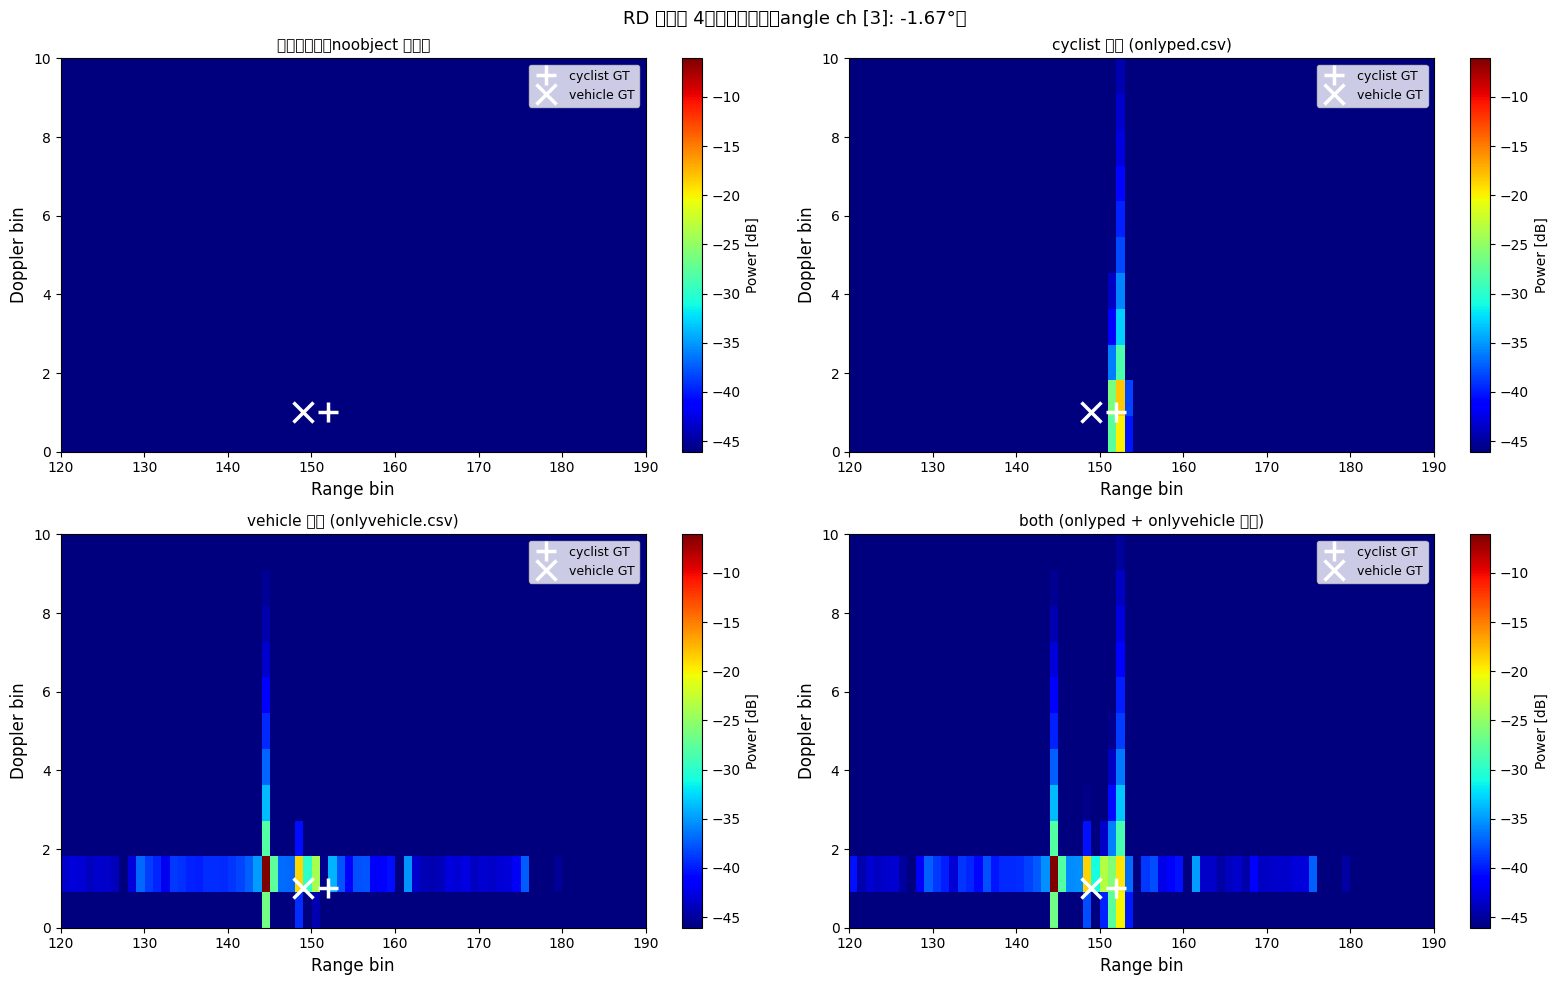

docs/simulation.md の仮説を RD マップで評価する

[仮説3: 車両のレンジビンずれ]
  GT           : (d=1, r=149)
  実ピーク     : (d=1, r=144)
  ずれ         : -5 bin  (-1.91 m)
  docs 予測    : -3〜-5 bin（近距離側）
  → 仮説と一致

[仮説1: 多重反射路の混入]
  有意ピーク閾値: -26.1 dB（ピーク -20 dB 以内）
  真値近傍（±2d, ±5r）以外の有意ピーク数: 0

[仮説2: 速度付与バグ（反射路に vehicle 速度が付与される）]
  vehicle Doppler bin: 1
  多重反射ピーク検出なし → 現シナリオでは多重反射は閾値以下

[注意: 建物のみ反射（noobject.csv）]
  rx_multiple にはビル専用チャネルがないため未評価。
  実際の NLOS 環境では Doppler≈0 付近にクラッタが乗り、低速ターゲットが
  隠れるリスクがある。現シミュレーションはこの成分を過小評価している。

検出困難パターンのまとめ
  1. 多重反射路が vehicle Doppler bin に固まりレンジ方向に偽ピーク
     → False Positive 増加リスク
  2. cyclist (r=152, d=1) / vehicle (r=149, d=1): Δr=+3 bin, Δd=+0 bin
     → 近接2ターゲットが1ターゲットとして検出される False Negative リスク
  3. レンジビンずれ: GT より近距離側に実ピーク → 座標精度の低下
  4. 建物のみ反射（Doppler≈0）は現シミュレーション未考慮
     → 実運用では低速ターゲット付近のクラッタが追加される


In [5]:
# ---- 目的1: 各シナリオのRDマップを生成・比較 ----

P_N_dB = -87.98

# ターゲット座標（0601meeting/rad_from_csv.ipynb から引き継ぎ）
p_bs = np.array([250, -18, 50])
p_cy = np.array([[-40, -6, 1]])
p_ve = np.array([[-39.2087, -7.90536, 1]])
v_cy = np.array([[6, 0, 0]])
v_ve = np.array([[10, 0, 0]])

# 物理量と真値 RD ビン
phys = env.phys_quantities(
    p_bs, p_cy, v_cy, 1, p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
cy_range = float(phys['range']['cyclists'][0])
cy_vel   = float(phys['relative_velocity']['cyclists'][0])
cy_ang   = float(np.degrees(phys['angle']['cyclists'][0]))
ve_range = float(phys['range']['vehicles'][0])
ve_vel   = float(phys['relative_velocity']['vehicles'][0])
ve_ang   = float(np.degrees(phys['angle']['vehicles'][0]))

cy_d, cy_r, _ = physical_to_rd_indices(cy_range, cy_vel, N_trans, T_symbol, lam, Tc)
ve_d, ve_r, _ = physical_to_rd_indices(ve_range, ve_vel, N_trans, T_symbol, lam, Tc)

print(f'cyclist  真値: range={cy_range:.1f} m, vel={cy_vel:.2f} m/s, angle={cy_ang:.2f}°  → d={cy_d}, r={cy_r}')
print(f'vehicle  真値: range={ve_range:.1f} m, vel={ve_vel:.2f} m/s, angle={ve_ang:.2f}°  → d={ve_d}, r={ve_r}')

# --- CSV 読み込み ---
tstemp_cy, P_rx_cy, phase_cy = load_cir_csv(CSV_ONLY_PED, Tc,9)
tstemp_ve, P_rx_ve, phase_ve = load_cir_csv(CSV_ONLY_VE, Tc,9)

print(f'\nonlyped.csv    : {len(tstemp_cy)} rays, 遅延 {tstemp_cy.min():.0f}〜{tstemp_cy.max():.0f} sample')
print(f'onlyvehicle.csv: {len(tstemp_ve)} rays, 遅延 {tstemp_ve.min():.0f}〜{tstemp_ve.max():.0f} sample')

# --- シナリオ1: cyclist のみ ---
env.phys_quantities(
    p_bs, p_cy, v_cy, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
Y_cy = env.rx_multiple(
    tx,
    [P_rx_cy], [tstemp_cy], [phase_cy],
    [], [], [], [], [], [],
    P_N_dB, T_symbol, N_trans
)

# --- シナリオ2: vehicle のみ ---
env.phys_quantities(
    p_bs,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
Y_ve = env.rx_multiple(
    tx,
    [], [], [],
    [P_rx_ve], [tstemp_ve], [phase_ve],
    [], [], [],
    P_N_dB, T_symbol, N_trans
)

# --- シナリオ3: both（onlyped + onlyvehicle を正しい物理量で合成）---
# both.csv は両ターゲットの合成応答のため rx_multiple の分離入力に対応しない。
# 個別 CSV を cyclist/vehicle チャネルに分けて渡すことで代替する。
env.phys_quantities(
    p_bs, p_cy, v_cy, 1, p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
Y_both = env.rx_multiple(
    tx,
    [P_rx_cy], [tstemp_cy], [phase_cy],
    [P_rx_ve], [tstemp_ve], [phase_ve],
    [], [], [],
    P_N_dB, T_symbol, N_trans
)

# --- シナリオ4: ノイズのみ（noobject.csv 近似）---
# noobject.csv の建物反射は rx_multiple に渡す手段がない（ターゲット種別なし）。
# 熱雑音のみで代用。実際の NLOS 環境では Doppler≈0 にクラッタが乗る点に注意。
env.phys_quantities(
    p_bs,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
Y_noise = env.rx_multiple(
    tx, [], [], [], [], [], [], [], [], [],
    P_N_dB, T_symbol, N_trans
)

# 最終状態を both に戻す
env.phys_quantities(
    p_bs, p_cy, v_cy, 1, p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

# --- RD マップ生成 (N_FIXED, N_trans, 190) ---
def gen_rd_maps(Y):
    rd_list = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, FIXED_ANGLES, T_symbol, lam, Tc, env)
    return np.array(rd_list[::2], dtype=np.complex64)

rd_cy    = gen_rd_maps(Y_cy)
rd_ve    = gen_rd_maps(Y_ve)
rd_both  = gen_rd_maps(Y_both)
rd_noise = gen_rd_maps(Y_noise)
print(f'\nRD マップ形状: {rd_cy.shape}  (N_FIXED, N_trans, N_range)')

# --- 可視化: 4 シナリオ 2×2 比較 ---
# cyclist と vehicle の真値角度の中間に最も近いチャネルを表示
best_ang = (cy_ang + ve_ang) / 2.0
best_ch  = int(np.argmin(np.abs(FIXED_ANGLES - best_ang)))
print(f'表示チャネル: [{best_ch}] {FIXED_ANGLES[best_ch]:.2f}°  (cy={cy_ang:.2f}°, ve={ve_ang:.2f}°)')

scenarios = [
    (rd_noise, 'ノイズのみ（noobject 近似）'),
    (rd_cy,    'cyclist のみ (onlyped.csv)'),
    (rd_ve,    'vehicle のみ (onlyvehicle.csv)'),
    (rd_both,  'both (onlyped + onlyvehicle 合成)'),
]

vmax_db = 10 * np.log10(np.abs(rd_both[best_ch]).max() ** 2 + 1e-30)
vmin_db = vmax_db - 40
R_LO, R_HI = 120, 190
D_LO, D_HI = 0, 10

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (rd, title) in zip(axes.flatten(), scenarios):
    power_db = 10 * np.log10(np.abs(rd[best_ch]) ** 2 + 1e-30)
    im = ax.imshow(
        power_db[D_LO:D_HI + 1, R_LO:R_HI + 1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=vmin_db, vmax=vmax_db,
        extent=[R_LO, R_HI, D_LO, D_HI]
    )
    ax.plot(cy_r, cy_d, 'w+',  markersize=14, markeredgewidth=2.5, label='cyclist GT')
    ax.plot(ve_r, ve_d, 'wx',  markersize=14, markeredgewidth=2.5, label='vehicle GT')
    ax.set_xlabel('Range bin', fontsize=12)
    ax.set_ylabel('Doppler bin', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax).set_label('Power [dB]', fontsize=10)

plt.suptitle(f'RD マップ 4シナリオ比較（angle ch [{best_ch}]: {FIXED_ANGLES[best_ch]:.2f}°）', fontsize=13)
plt.tight_layout()
plt.savefig('goal1_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 仮説評価（docs/simulation.md の3仮説を RD マップで確認）---
print('=' * 60)
print('docs/simulation.md の仮説を RD マップで評価する')
print('=' * 60)

ve_best_ch = int(np.argmin(np.abs(FIXED_ANGLES - ve_ang)))
rd_ve_ch   = rd_ve[ve_best_ch]    # (N_trans, 190)
power_ve   = 10 * np.log10(np.abs(rd_ve_ch) ** 2 + 1e-30)
vmax_ve    = power_ve.max()

# 仮説3: 車両のレンジビンずれ
ve_peak_d, ve_peak_r = np.unravel_index(np.argmax(np.abs(rd_ve_ch)), rd_ve_ch.shape)
range_res  = l_speed * Tc / 2.0
shift_bins = ve_peak_r - ve_r

print(f'\n[仮説3: 車両のレンジビンずれ]')
print(f'  GT           : (d={ve_d}, r={ve_r})')
print(f'  実ピーク     : (d={ve_peak_d}, r={ve_peak_r})')
print(f'  ずれ         : {shift_bins:+d} bin  ({shift_bins * range_res:+.2f} m)')
print(f'  docs 予測    : -3〜-5 bin（近距離側）')
if -5 <= shift_bins <= -3:
    print('  → 仮説と一致')
elif -2 <= shift_bins <= 0:
    print('  → ずれは小さい（仮説より軽微）')
elif shift_bins > 0:
    print('  → 遠距離側にずれ（仮説と逆方向）')
else:
    print('  → 仮説より大きくずれている')

# 仮説1 + 仮説2: 多重反射路の混入 と 速度付与バグ
# 真値近傍（±2 Doppler bin, ±5 range bin）以外にある有意ピークを多重反射とみなす
threshold = vmax_ve - 20    # ピーク -20 dB 以内を有意と判断

multipaths = [
    (d, r, power_ve[d, r])
    for d in range(power_ve.shape[0])
    for r in range(power_ve.shape[1])
    if power_ve[d, r] >= threshold and not (abs(d - ve_d) <= 2 and abs(r - ve_r) <= 5)
]
multipaths.sort(key=lambda x: -x[2])

print(f'\n[仮説1: 多重反射路の混入]')
print(f'  有意ピーク閾値: {threshold:.1f} dB（ピーク -20 dB 以内）')
print(f'  真値近傍（±2d, ±5r）以外の有意ピーク数: {len(multipaths)}')
for d, r, p in multipaths[:6]:
    print(f'    (d={d:3d}, r={r:3d})  {p:.1f} dB  Δr={r - ve_r:+d}  Δd={d - ve_d:+d}')

print(f'\n[仮説2: 速度付与バグ（反射路に vehicle 速度が付与される）]')
print(f'  vehicle Doppler bin: {ve_d}')
if multipaths:
    near = sum(1 for d, r, _ in multipaths if abs(d - ve_d) <= 1)
    print(f'  多重反射 {len(multipaths)} ピーク中 vehicle Doppler ±1 bin: {near} ピーク')
    ratio = near / len(multipaths)
    if ratio >= 1.0:
        print('  → 全ピークが vehicle Doppler に集中 → 速度バグ仮説と一致')
    elif ratio >= 0.5:
        print('  → 大半が vehicle Doppler に集中 → 速度バグ仮説を概ね支持')
    else:
        print('  → Doppler が分散 → 速度バグ仮説と不一致（要追加調査）')
else:
    print('  多重反射ピーク検出なし → 現シナリオでは多重反射は閾値以下')

print(f'\n[注意: 建物のみ反射（noobject.csv）]')
print(f'  rx_multiple にはビル専用チャネルがないため未評価。')
print(f'  実際の NLOS 環境では Doppler≈0 付近にクラッタが乗り、低速ターゲットが')
print(f'  隠れるリスクがある。現シミュレーションはこの成分を過小評価している。')

# 難しいパターンのまとめ
print(f'\n{"=" * 60}')
print(f'検出困難パターンのまとめ')
print(f'{"=" * 60}')
print(f'  1. 多重反射路が vehicle Doppler bin に固まりレンジ方向に偽ピーク')
print(f'     → False Positive 増加リスク')
print(f'  2. cyclist (r={cy_r}, d={cy_d}) / vehicle (r={ve_r}, d={ve_d}): '
      f'Δr={cy_r - ve_r:+d} bin, Δd={cy_d - ve_d:+d} bin')
print(f'     → 近接2ターゲットが1ターゲットとして検出される False Negative リスク')
print(f'  3. レンジビンずれ: GT より近距離側に実ピーク → 座標精度の低下')
print(f'  4. 建物のみ反射（Doppler≈0）は現シミュレーション未考慮')
print(f'     → 実運用では低速ターゲット付近のクラッタが追加される')

noobject.csv: 9 rays, 遅延 25〜439 sample


C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\3552351953.py:49: UserWarning: Glyph 12398 (\

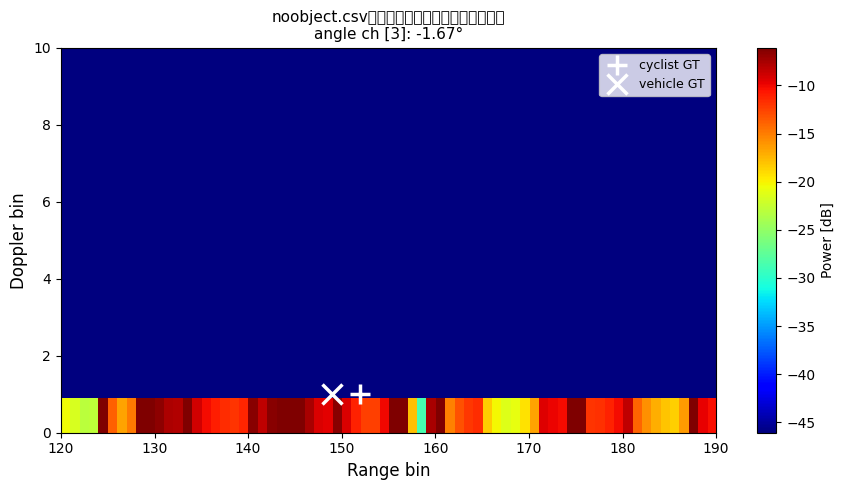

In [6]:
# ---- 目的1 追加: noobject.csv の建物反射 RD マップ ----
# cyclist チャネルに速度ゼロで渡すことで fd=0 → Doppler bin 0 に集中
# ステアリングベクトルは p_cy 方向に固定（建物の多方向反射は近似）
# noobject.csv はターゲットなし → 行数が少ないので skip=0

tstemp_no, P_rx_no, phase_no = load_cir_csv(CSV_NO_OBJECT, Tc, skip=0)
print(f'noobject.csv: {len(tstemp_no)} rays, 遅延 {tstemp_no.min():.0f}〜{tstemp_no.max():.0f} sample')

env.phys_quantities(
    p_bs,
    p_cy, np.zeros((1, 3)), 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)
Y_no = env.rx_multiple(
    tx,
    [P_rx_no], [tstemp_no], [phase_no],
    [], [], [], [], [], [],
    P_N_dB, T_symbol, N_trans
)
rd_no = gen_rd_maps(Y_no)  # (N_FIXED, N_trans, 190)

# 最終状態を both に戻す
env.phys_quantities(
    p_bs, p_cy, v_cy, 1, p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

# --- 可視化 ---
power_no_db = 10 * np.log10(np.abs(rd_no[best_ch]) ** 2 + 1e-30)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    power_no_db[D_LO:D_HI + 1, R_LO:R_HI + 1],
    aspect='auto', origin='lower', cmap='jet',
    vmin=vmin_db, vmax=vmax_db,
    extent=[R_LO, R_HI, D_LO, D_HI]
)
ax.plot(cy_r, cy_d, 'w+', markersize=14, markeredgewidth=2.5, label='cyclist GT')
ax.plot(ve_r, ve_d, 'wx', markersize=14, markeredgewidth=2.5, label='vehicle GT')
ax.set_xlabel('Range bin', fontsize=12)
ax.set_ylabel('Doppler bin', fontsize=12)
ax.set_title(
    f'noobject.csv（建物反射のみ、速度ゼロ近似）\nangle ch [{best_ch}]: {FIXED_ANGLES[best_ch]:.2f}°',
    fontsize=11
)
ax.legend(fontsize=9)
plt.colorbar(im, ax=ax).set_label('Power [dB]', fontsize=10)
plt.tight_layout()
plt.savefig('goal1_noobject_rd.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(sorted(tstemp_no[:20].astype(int)))  # 最初の20行の遅延値

[np.int64(25), np.int64(98), np.int64(131), np.int64(136), np.int64(138), np.int64(141), np.int64(144), np.int64(271), np.int64(439)]


---
## 目的2: チャープ数削減によるRDマップへの影響確認

ISACのトレードオフ（通信時間確保のためセンシング時間＝チャープ数が削減）で
検出がどれだけ難しくなるかを定量的に示す。

チャープ数別のドップラー分解能:
   N_chirp   vel_res [m/s/bin]   vehicle d_idx   cyclist d_idx
        89             10.7894               1               1  ← 合流（分離不可）
        60             16.0043               1               0
        22             43.6481               0               0  ← 合流（分離不可）


C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 12481 (\N{KATAKANA LETTER TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 12515 (\N{KATAKANA LETTER SMALL YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kousu\AppData\Local\Temp\ipykernel_12724\2506100879.py:79: UserWarning: Glyph 12540 (\N{KATAKANA

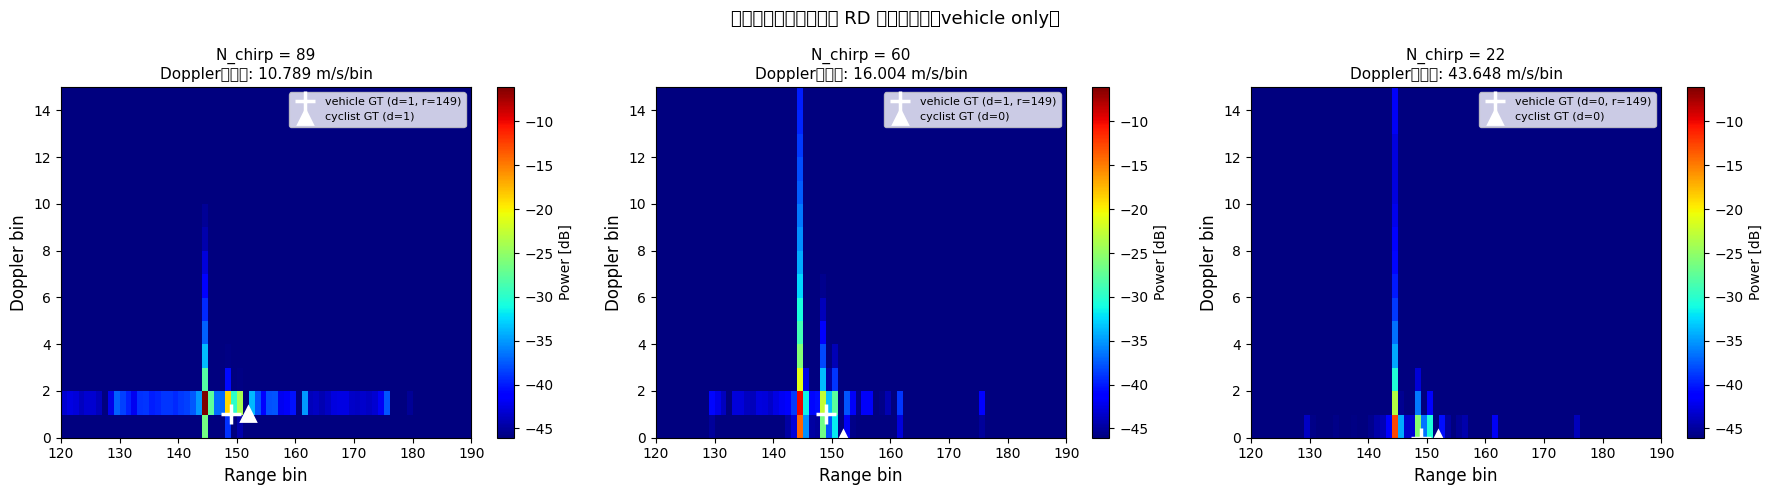


=== チャープ数削減の影響 ===
  N_chirp= 89: vel_res=10.7894 m/s  SNR≈78.8 dB  ★ cyclist/vehicle 合流（分離不可）
  N_chirp= 60: vel_res=16.0043 m/s  SNR≈74.1 dB  Δd=+1 bin
  N_chirp= 22: vel_res=43.6481 m/s  SNR≈70.6 dB  ★ cyclist/vehicle 合流（分離不可）


In [ ]:
# ---- 目的2: チャープ数削減によるRDマップへの影響確認 ----
# p_bs, p_cy, p_ve, v_cy, v_ve, cy_range, cy_vel, ve_range, ve_vel, ve_ang,
# tstemp_ve, P_rx_ve, phase_ve, P_N_dB は目的1で定義済み

N_trans_list = [89, 60, 22]
ve_best_ch = int(np.argmin(np.abs(FIXED_ANGLES - ve_ang)))

print('チャープ数別のドップラー分解能:')
print(f'  {"N_chirp":>8}  {"vel_res [m/s/bin]":>18}  {"vehicle d_idx":>14}  {"cyclist d_idx":>14}')
for n_t in N_trans_list:
    vel_res  = lam / (2.0 * T_symbol * n_t)
    ve_dt, _, _ = physical_to_rd_indices(ve_range, ve_vel, n_t, T_symbol, lam, Tc)
    cy_dt, _, _ = physical_to_rd_indices(cy_range, cy_vel, n_t, T_symbol, lam, Tc)
    merged = '  ← 合流（分離不可）' if ve_dt == cy_dt else ''
    print(f'  {n_t:>8}  {vel_res:>18.4f}  {ve_dt:>14}  {cy_dt:>14}{merged}')

# --- チャープ数ごとに RD マップ生成（vehicle only で比較）---
rd_by_ntrans = {}

for n_t in N_trans_list:
    env.phys_quantities(
        p_bs,
        np.zeros((0, 3)), np.zeros((0, 3)), 0,
        p_ve, v_ve, 1,
        np.zeros((0, 3)), np.zeros((0, 3)), 0
    )
    Y_t = env.rx_multiple(
        tx,
        [], [], [],
        [P_rx_ve], [tstemp_ve], [phase_ve],
        [], [], [],
        P_N_dB, T_symbol, n_t
    )
    rd_list = FFT(n_t, N_ant, rx_sample, Y_t, tx, N_sample, FIXED_ANGLES, T_symbol, lam, Tc, env)
    rd_by_ntrans[n_t] = np.array(rd_list[::2], dtype=np.complex64)  # (N_FIXED, n_t, 190)

# 最終状態を both に戻す
env.phys_quantities(
    p_bs, p_cy, v_cy, 1, p_ve, v_ve, 1,
    np.zeros((0, 3)), np.zeros((0, 3)), 0
)

# --- 可視化: 3チャープ数を横並びで比較 ---
R_LO2, R_HI2 = 120, 190

# N_trans=89（左端）のピーク電力を全サブプロット共通の基準にする
rd_ref   = rd_by_ntrans[N_trans_list[0]]
vmax_ref = 10 * np.log10(np.abs(rd_ref[ve_best_ch]) ** 2 + 1e-30).max()
vmin_ref = vmax_ref - 40

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n_t in zip(axes, N_trans_list):
    rd_t   = rd_by_ntrans[n_t]
    d_ve, r_ve, _ = physical_to_rd_indices(ve_range, ve_vel, n_t, T_symbol, lam, Tc)
    d_cy, r_cy, _ = physical_to_rd_indices(cy_range, cy_vel, n_t, T_symbol, lam, Tc)
    vel_res = lam / (2.0 * T_symbol * n_t)
    d_max   = min(n_t, 15)

    power_db = 10 * np.log10(np.abs(rd_t[ve_best_ch]) ** 2 + 1e-30)

    im = ax.imshow(
        power_db[:d_max, R_LO2:R_HI2 + 1],
        aspect='auto', origin='lower', cmap='jet',
        vmin=vmin_ref, vmax=vmax_ref,
        extent=[R_LO2, R_HI2, 0, d_max]
    )
    """ax.plot(r_ve, d_ve, 'w+', markersize=14, markeredgewidth=2.5,
            label=f'vehicle GT (d={d_ve}, r={r_ve})')
    ax.plot(r_cy, d_cy, 'w^', markersize=10, markeredgewidth=2,
            label=f'cyclist GT (d={d_cy})')
    """
    ax.set_xlabel('Range bin', fontsize=12)
    ax.set_ylabel('Doppler bin', fontsize=12)
    ax.set_title(f'N_chirp = {n_t}\nDoppler分解能: {vel_res:.3f} m/s/bin', fontsize=11)
    ax.legend(fontsize=8)
    plt.colorbar(im, ax=ax).set_label('Power [dB]', fontsize=10)

plt.suptitle('チャープ数削減による RD マップ変化（vehicle only）', fontsize=13)
plt.tight_layout()
plt.savefig('goal2_chirp_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 定量評価 ---
print('\n=== チャープ数削減の影響 ===')
for n_t in N_trans_list:
    vel_res = lam / (2.0 * T_symbol * n_t)
    d_ve, r_ve, _ = physical_to_rd_indices(ve_range, ve_vel, n_t, T_symbol, lam, Tc)
    d_cy, r_cy, _ = physical_to_rd_indices(cy_range, cy_vel, n_t, T_symbol, lam, Tc)
    p_db   = 10 * np.log10(np.abs(rd_by_ntrans[n_t][ve_best_ch]) ** 2 + 1e-30)
    peak   = p_db.max()
    noise  = np.percentile(p_db, 5)    # 下位 5% をノイズ床とみなす
    snr    = peak - noise
    status = '★ cyclist/vehicle 合流（分離不可）' if d_ve == d_cy else f'Δd={d_ve - d_cy:+d} bin'
    print(f'  N_chirp={n_t:3d}: vel_res={vel_res:.4f} m/s  SNR≈{snr:.1f} dB  {status}')